In [1]:
%pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 6.8 MB/s eta 0:00:00


In [160]:
from pyod.utils.data import generate_data
from pyod.models.ocsvm import OCSVM
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, make_scorer
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from pyod.models.deep_svdd import DeepSVDD
import scipy.io
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import  Pipeline
from sklearn.svm import OneClassSVM

In [143]:
X_train, X_test, y_train, y_test = generate_data(n_train=300, n_test=200, n_features=3, contamination=0.15)

In [144]:
model = OCSVM(contamination=0.15, kernel='linear')

model.fit(X_train)

preds_test = model.predict(X_test)
score_test = model.decision_function(X_test)
preds_train = model.predict(X_train)

print(balanced_accuracy_score(y_test, preds_test), roc_auc_score(y_test, score_test))


0.9470588235294117 0.9976470588235293


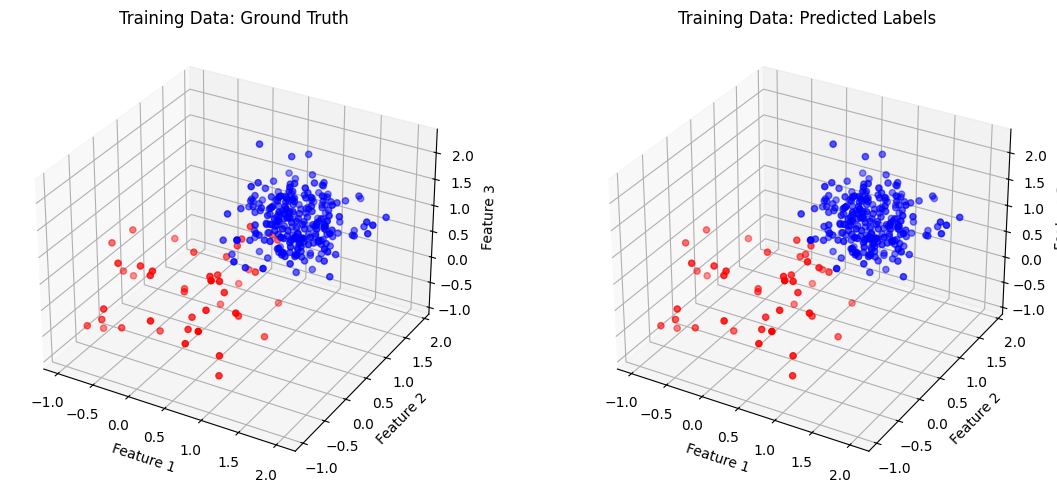

In [145]:
fig = plt.figure(figsize=(12, 5))

c_train_gt =["r" if x == 1 else "b" for x in y_train]
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=c_train_gt, s=20)
ax1.set_title('Training Data: Ground Truth')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_zlabel('Feature 3')

c_train_preds =["r" if x == 1 else "b" for x in preds_train]
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=c_train_preds, s=20)
ax2.set_title('Training Data: Predicted Labels')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_zlabel('Feature 3')

plt.tight_layout()
plt.show()

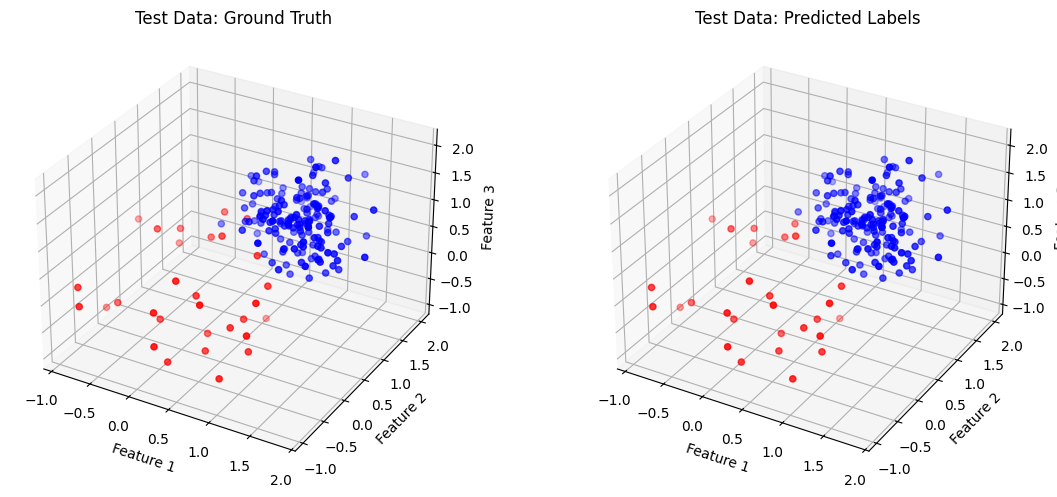

In [146]:
fig = plt.figure(figsize=(12, 5))

c_test_gt =["r" if x == 1 else "b" for x in y_test]
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=c_test_gt, s=20)
ax1.set_title('Test Data: Ground Truth')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_zlabel('Feature 3')

c_test_pred =["r" if x == 1 else "b" for x in preds_test]
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=c_test_pred, s=20)
ax2.set_title('Test Data: Predicted Labels')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_zlabel('Feature 3')

plt.tight_layout()
plt.show()

In [147]:
model = OCSVM(contamination=0.15, kernel='rbf')

model.fit(X_train)

preds_test = model.predict(X_test)
score_test = model.decision_function(X_test)
preds_train = model.predict(X_train)

print(balanced_accuracy_score(y_test, preds_test), roc_auc_score(y_test, score_test))

0.888235294117647 0.9439215686274509


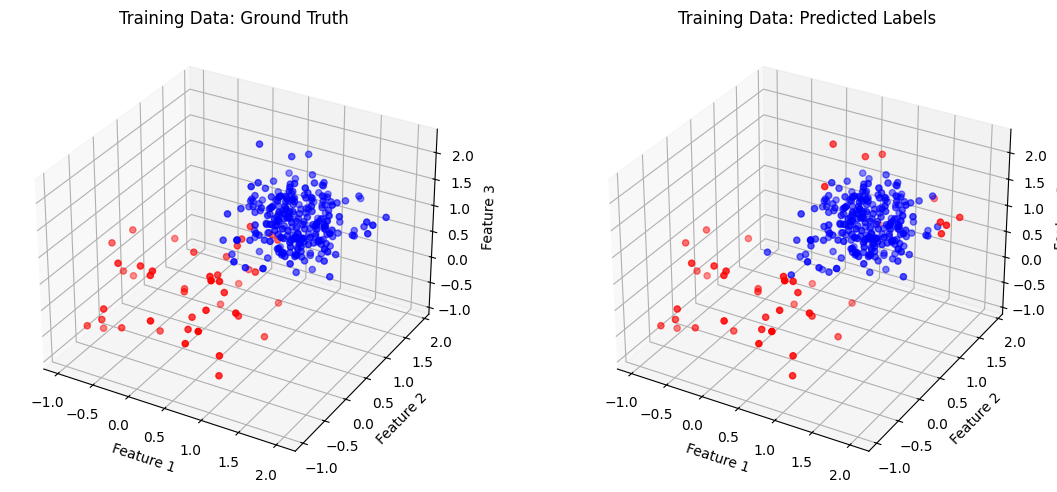

In [148]:
fig = plt.figure(figsize=(12, 5))

c_train_gt =["r" if x == 1 else "b" for x in y_train]
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=c_train_gt, s=20)
ax1.set_title('Training Data: Ground Truth')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_zlabel('Feature 3')

c_train_preds =["r" if x == 1 else "b" for x in preds_train]
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=c_train_preds, s=20)
ax2.set_title('Training Data: Predicted Labels')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_zlabel('Feature 3')

plt.tight_layout()
plt.show()

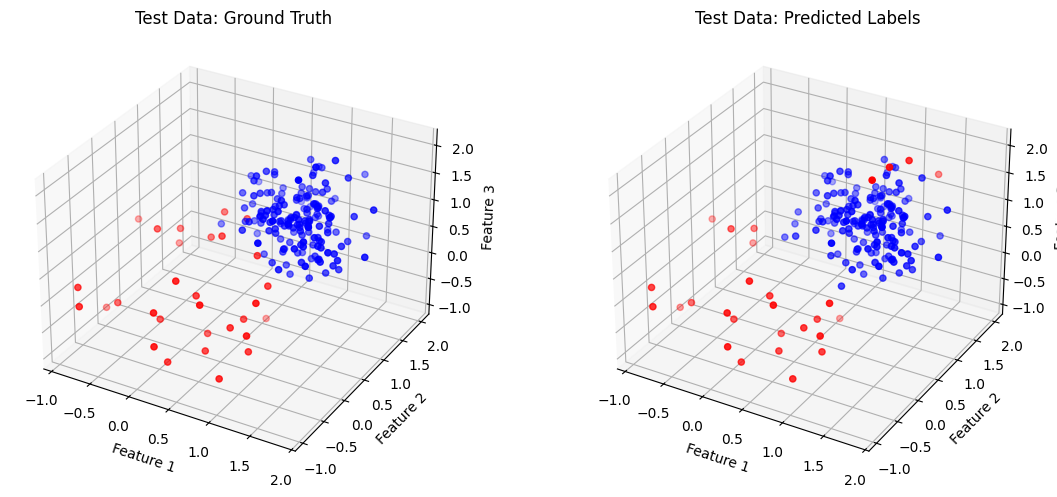

In [149]:
fig = plt.figure(figsize=(12, 5))

c_test_gt =["r" if x == 1 else "b" for x in y_test]
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=c_test_gt, s=20)
ax1.set_title('Test Data: Ground Truth')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_zlabel('Feature 3')

c_test_pred =["r" if x == 1 else "b" for x in preds_test]
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=c_test_pred, s=20)
ax2.set_title('Test Data: Predicted Labels')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_zlabel('Feature 3')

plt.tight_layout()
plt.show()

In [150]:
model = DeepSVDD(3,contamination=0.15)

model.fit(X_train)

preds_test = model.predict(X_test)
score_test = model.decision_function(X_test)
preds_train = model.predict(X_train)

print(balanced_accuracy_score(y_test, preds_test), roc_auc_score(y_test, score_test))

Epoch 1/100, Loss: 8.721984505653381
Epoch 2/100, Loss: 8.784941792488098
Epoch 3/100, Loss: 9.16724282503128
Epoch 4/100, Loss: 8.501466989517212
Epoch 5/100, Loss: 8.783945590257645
Epoch 6/100, Loss: 9.279712736606598
Epoch 7/100, Loss: 9.268194198608398
Epoch 8/100, Loss: 9.424576669931412
Epoch 9/100, Loss: 9.299833446741104
Epoch 10/100, Loss: 9.120919555425644
Epoch 11/100, Loss: 9.115761309862137
Epoch 12/100, Loss: 8.56509929895401
Epoch 13/100, Loss: 8.56595429778099
Epoch 14/100, Loss: 9.03258702158928
Epoch 15/100, Loss: 9.630406767129898
Epoch 16/100, Loss: 8.78516161441803
Epoch 17/100, Loss: 8.874779641628265
Epoch 18/100, Loss: 8.756597846746445
Epoch 19/100, Loss: 9.226371139287949
Epoch 20/100, Loss: 9.01112151145935
Epoch 21/100, Loss: 8.61428040266037
Epoch 22/100, Loss: 9.128917932510376
Epoch 23/100, Loss: 9.50558078289032
Epoch 24/100, Loss: 8.883507460355759
Epoch 25/100, Loss: 9.022486090660095
Epoch 26/100, Loss: 8.997275590896606
Epoch 27/100, Loss: 8.7330046

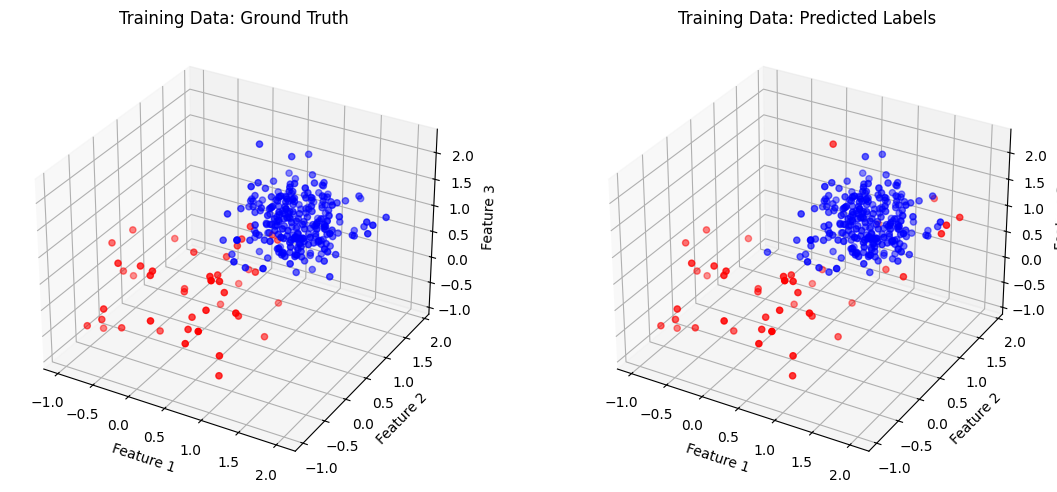

In [151]:
fig = plt.figure(figsize=(12, 5))

c_train_gt =["r" if x == 1 else "b" for x in y_train]
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=c_train_gt, s=20)
ax1.set_title('Training Data: Ground Truth')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_zlabel('Feature 3')

c_train_preds =["r" if x == 1 else "b" for x in preds_train]
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=c_train_preds, s=20)
ax2.set_title('Training Data: Predicted Labels')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_zlabel('Feature 3')

plt.tight_layout()
plt.show()

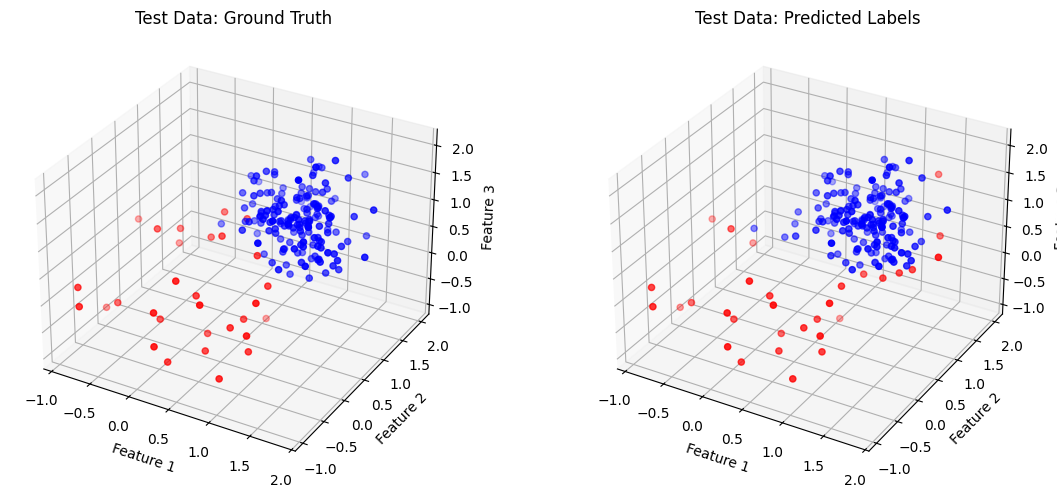

In [152]:
fig = plt.figure(figsize=(12, 5))

c_test_gt =["r" if x == 1 else "b" for x in y_test]
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=c_test_gt, s=20)
ax1.set_title('Test Data: Ground Truth')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_zlabel('Feature 3')

c_test_pred =["r" if x == 1 else "b" for x in preds_test]
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=c_test_pred, s=20)
ax2.set_title('Test Data: Predicted Labels')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_zlabel('Feature 3')

plt.tight_layout()
plt.show()

EX2

In [166]:
mat = scipy.io.loadmat('/content/cardio 1.mat')

X = mat['X']
y = mat['y'].ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.4, stratify=y)

y_train = 1 - 2 * y_train
y_test = 1 - 2 * y_test

n_outliers = np.sum(y_train == -1)
n_samples = len(y_train)
contamination_rate = n_outliers / n_samples
print(contamination_rate)

param_grid = {
    'clf__kernel': ['rbf', 'linear', 'sigmoid', 'poly'],
    'clf__gamma': ['scale', 'auto', 0.001, 0.1],
    'clf__nu': [0.01, 0.1, 0.2, contamination_rate]
}

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', OneClassSVM())
])

scorer = make_scorer(balanced_accuracy_score)

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

final_score = balanced_accuracy_score(y_test, y_pred)

print(f"Balanced Accuracy on Test Set: {final_score:.4f}")

0.09562841530054644
Fitting 5 folds for each of 64 candidates, totalling 320 fits
{'clf__gamma': 0.001, 'clf__kernel': 'rbf', 'clf__nu': 0.2}
Balanced Accuracy on Test Set: 0.8591


EX3

In [177]:
mat = scipy.io.loadmat('/content/shuttle 1.mat')

X = mat['X']
y = mat['y'].ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_outliers = np.sum(y_train == 1)
n_samples = len(y_train)
contamination_rate = n_outliers / n_samples
print(contamination_rate)


model = OCSVM(contamination=contamination_rate)

model.fit(X_train_scaled)
pred_test = model.predict(X_test_scaled)
score_test = model.decision_function(X_test_scaled)

print(f"OCSVM BA:{balanced_accuracy_score(y_test, pred_test)}, ROC_AUC{roc_auc_score(y_test, score_test)}")

model2 = DeepSVDD(n_features=X_train_scaled.shape[1], epochs=20)
model2.fit(X_train_scaled)
pred_test = model2.predict(X_test_scaled)
score_test = model2.decision_function(X_test_scaled)

print(f"DeepSVDD BA:{balanced_accuracy_score(y_test, pred_test)}, ROC_AUC{roc_auc_score(y_test, score_test)}")

0.07149258595404921
OCSVM BA:0.9746565654223657, ROC_AUC0.9923201804254534
Epoch 1/20, Loss: 652.7227084636688
Epoch 2/20, Loss: 652.7828443348408
Epoch 3/20, Loss: 652.9477810412645
Epoch 4/20, Loss: 652.8821351230145
Epoch 5/20, Loss: 653.3332485258579
Epoch 6/20, Loss: 652.6248800903559
Epoch 7/20, Loss: 653.3772399872541
Epoch 8/20, Loss: 652.6554757654667
Epoch 9/20, Loss: 652.8972444087267
Epoch 10/20, Loss: 652.9151360690594
Epoch 11/20, Loss: 652.7904334068298
Epoch 12/20, Loss: 652.8078961372375
Epoch 13/20, Loss: 652.837029710412
Epoch 14/20, Loss: 654.2619111388922
Epoch 15/20, Loss: 654.0277175754309
Epoch 16/20, Loss: 654.7442528754473
Epoch 17/20, Loss: 653.9670086950064
Epoch 18/20, Loss: 652.6830116212368
Epoch 19/20, Loss: 654.019355148077
Epoch 20/20, Loss: 652.9348624646664
DeepSVDD BA:0.966246555735301, ROC_AUC0.9890603777065793


In [178]:
architectures = [
    [32, 16],
    [64, 32],
    [128, 64, 32],
    [256, 128, 64, 32]
]
print(X_train_scaled.shape)

for arch in architectures:

    clf = DeepSVDD(n_features=X_train_scaled.shape[1], hidden_neurons=arch, epochs=20, verbose=0)

    clf.fit(X_train_scaled)

    y_pred = clf.predict(X_test_scaled)
    y_scores = clf.decision_function(X_test_scaled)

    print(f"BA = {balanced_accuracy_score(y_test, y_pred)}, AUC = {roc_auc_score(y_test, y_scores)}")

(24548, 9)
Epoch 1/20, Loss: 439.6758164986968
Epoch 2/20, Loss: 439.57491666451097
Epoch 3/20, Loss: 439.7930387556553
Epoch 4/20, Loss: 439.6322482675314
Epoch 5/20, Loss: 439.632151260972
Epoch 6/20, Loss: 439.9975246191025
Epoch 7/20, Loss: 440.8690000027418
Epoch 8/20, Loss: 439.92599069327116
Epoch 9/20, Loss: 439.6084775701165
Epoch 10/20, Loss: 439.8567245602608
Epoch 11/20, Loss: 439.7285979539156
Epoch 12/20, Loss: 440.76280446350574
Epoch 13/20, Loss: 440.1976488903165
Epoch 14/20, Loss: 439.57335899211466
Epoch 15/20, Loss: 439.7167157456279
Epoch 16/20, Loss: 440.6817122846842
Epoch 17/20, Loss: 439.9544653594494
Epoch 18/20, Loss: 440.56166595220566
Epoch 19/20, Loss: 439.7590210288763
Epoch 20/20, Loss: 440.1007838919759
BA = 0.956234227788634, AUC = 0.981346728859228
Epoch 1/20, Loss: 600.9139902740717
Epoch 2/20, Loss: 600.8552676737309
Epoch 3/20, Loss: 600.9250384867191
Epoch 4/20, Loss: 601.3639523535967
Epoch 5/20, Loss: 600.8517199158669
Epoch 6/20, Loss: 600.7880